**Objetivo:** ¿Se puede predecir si una reseña será positiva (`voted_up`) utilizando aprendizaje supervisado basado en el texto y características del autor?

Utilizando los siguientes parametros:
- review_text
- author_playtime_at_review
- author_playtime_forever
- author_num_reviews (falta)
- author_num_games_owned
- votes_funny
- votes_up (falta)
- language

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_full = pd.read_csv('data/reviews.csv')
df = df_full.sample(frac=1.00, random_state=42).copy()

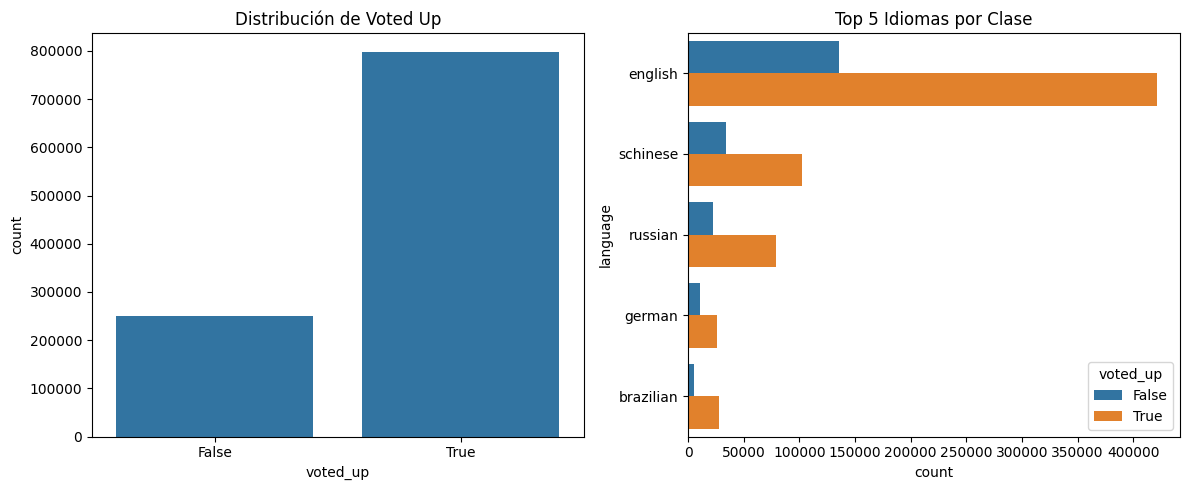

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="voted_up", ax=axes[0])
axes[0].set_title("Distribución de Voted Up")

sns.countplot(data=df, y="language", hue="voted_up", ax=axes[1], order=df['language'].value_counts().iloc[:5].index)
axes[1].set_title("Top 5 Idiomas por Clase")
plt.tight_layout()
plt.show()

**Desbalance de Clases (Voted Up):** La gran mayoría de las reseñas en el dataset son positivas. Aproximadamente el **76.1%** corresponden a recomendaciones (`voted_up = True`), frente a un **23.9%** de reseñas negativas. Esto indica que cualquier modelo de clasificación tendrá que lidiar con un desbalance de clases significativo.

**Idioma vs. Valoración (Top 5 Idiomas):** En los 5 idiomas principales (inglés, chino simplificado, ruso, alemán y portugués de Brasil) predomina la valoración positiva. **Portugués de Brasil** es el idioma con el mayor ratio de reseñas positivas (**~85%**), mientras que **Alemán** es el idioma del Top 5 con la mayor proporción de reseñas negativas (**~30%**). **Podemos enfocarnos en solo idioma inglés**

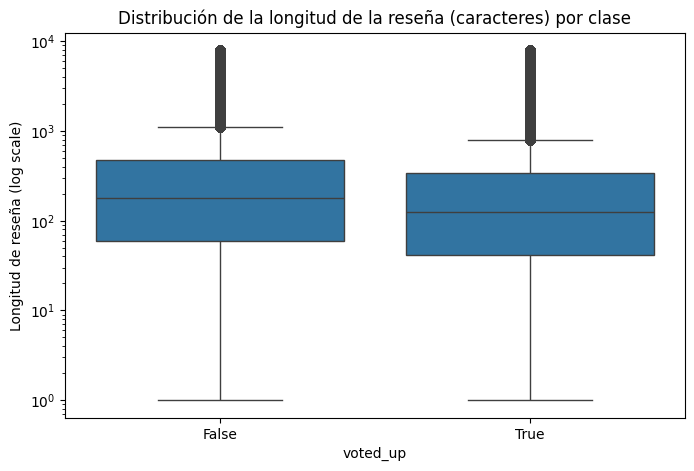

In [10]:
# Análisis de la longitud del texto de la reseña
df['review_length'] = df['review_text'].str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='voted_up', y='review_length')
plt.yscale('log')
plt.title("Distribución de la longitud de la reseña (caracteres) por clase")
plt.ylabel("Longitud de reseña (log scale)")
plt.show()

df.drop(columns=['review_length'], inplace=True)

**Longitud de la Reseña (`review_length`):** Las reseñas negativas tienden a ser notablemente más largas que las positivas. La mediana de caracteres para reseñas negativas es de **178**, mientras que para las positivas es de solo **126**.

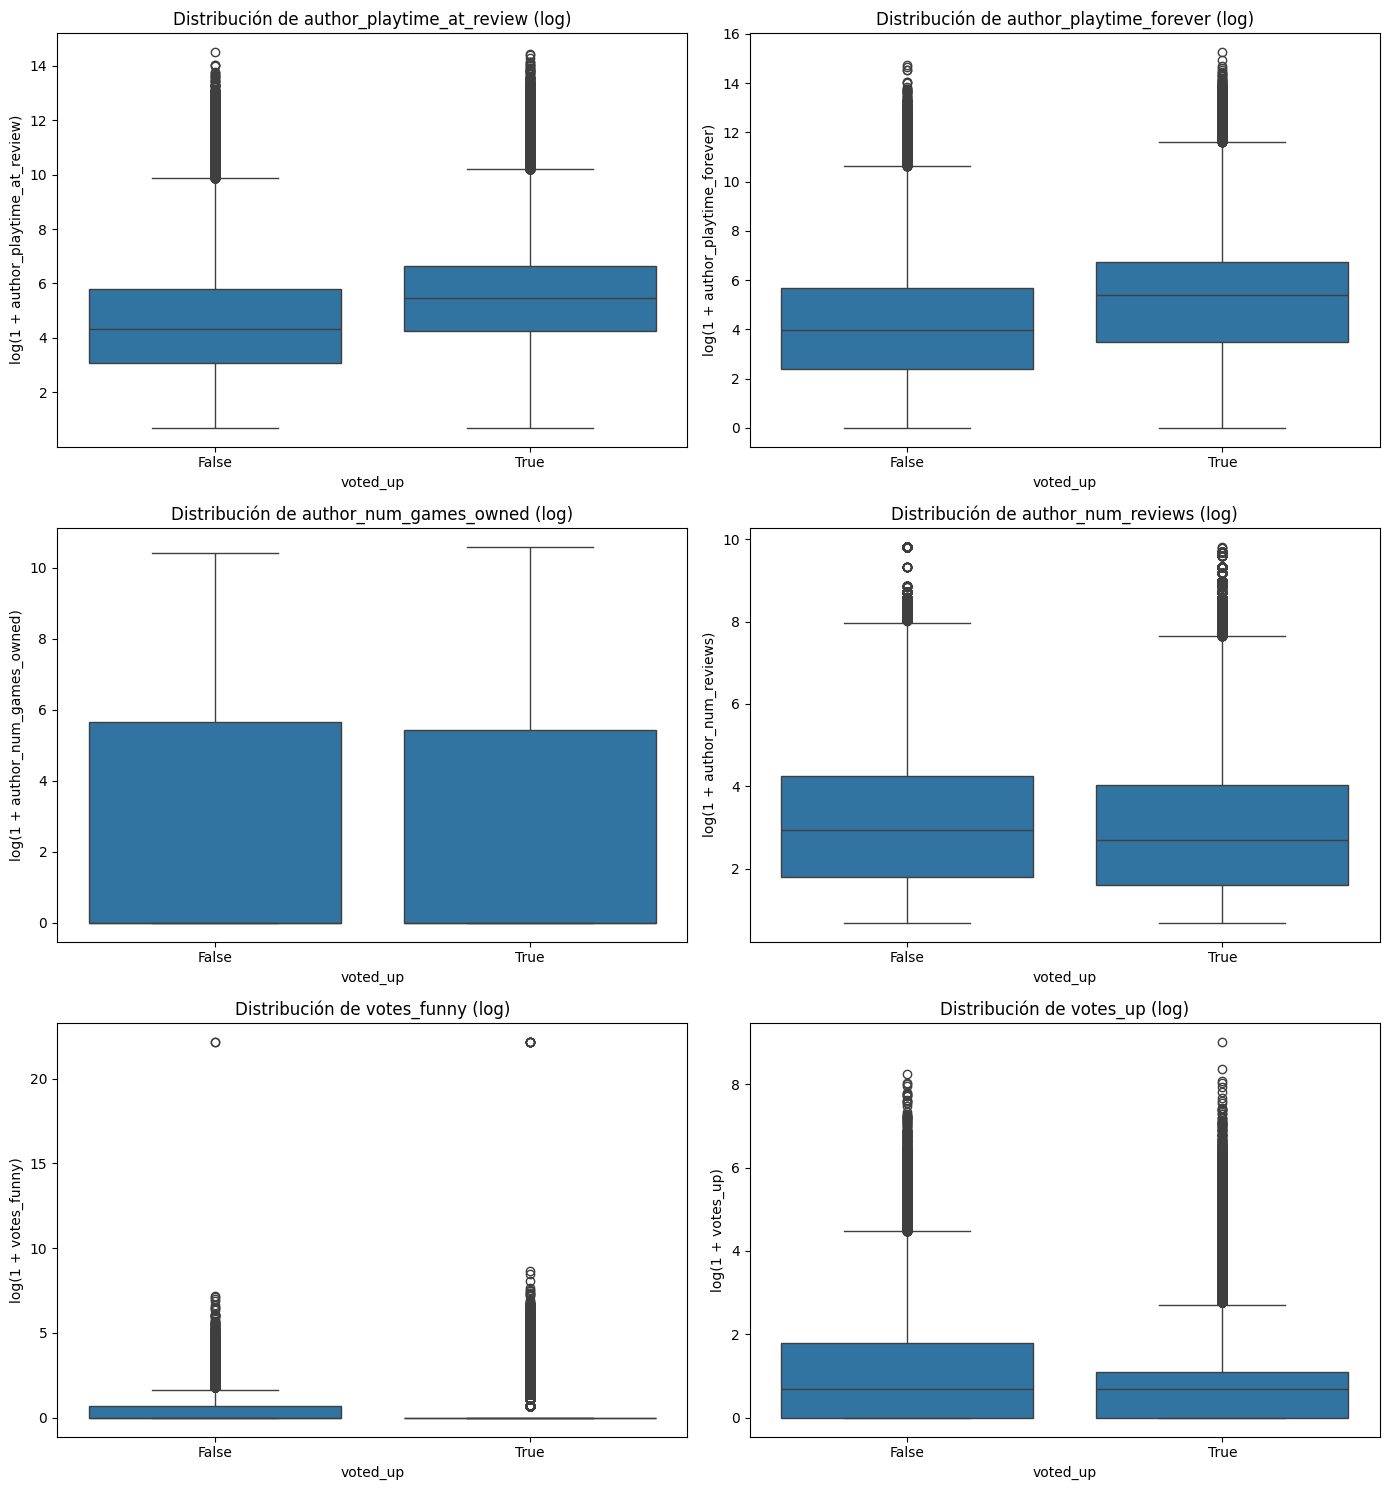

In [ ]:
# Distribución de variables numéricas por clase (voted_up)
# Aplicamos escala logarítmica (log1p) debido a la asimetría de los datos

fig, axes = plt.subplots**Tiempo de Juego al Momento de la Reseña (`author_playtime_at_review`):** La mediana de tiempo jugado al momento de escribir una reseña positiva es de **237 minutos** (casi 4 horas), comparado con solo **74 minutos** para las reseñas negativas. Los usuarios que dejan reseñas negativas tienden a abandonar el juego mucho antes.(3, 2, figsize=(14, 15))

# 1. Gráfica para author_playtime_at_review
df['author_playtime_at_review_log'] = np.log1p(df['author_playtime_at_review'])
sns.boxplot(data=df, x='voted_up', y='author_playtime_at_review_log', ax=axes[0, 0])
axes[0, 0].set_title("Distribución de author_playtime_at_review (log)")
axes[0, 0].set_ylabel("log(1 + author_playtime_at_review)")

# 2. Gráfica para author_playtime_forever
df['author_playtime_forever_log'] = np.log1p(df['author_playtime_forever'])
sns.boxplot(data=df, x='voted_up', y='author_playtime_forever_log', ax=axes[0, 1])
axes[0, 1].set_title("Distribución de author_playtime_forever (log)")
axes[0, 1].set_ylabel("log(1 + author_playtime_forever)")**Tiempo de Juego al Momento de la Reseña (`author_playtime_at_review`):** La mediana de tiempo jugado al momento de escribir una reseña positiva es de **237 minutos** (casi 4 horas), comparado con solo **74 minutos** para las reseñas negativas. Los usuarios que dejan reseñas negativas tienden a abandonar el juego mucho antes.

# 3. Gráfica para author_num_games_owned
df['author_num_games_owned_log'] = np.log1p(df['author_num_games_owned'])
sns.boxplot(data=df, x='voted_up', y='author_num_games_owned_log', ax=axes[1, 0])
axes[1, 0].set_title("Distribución de author_num_games_owned (log)")
axes[1, 0].set_ylabel("log(1 + author_num_games_owned)")

# 5. Gráfica para author_num_reviews
df['author_num_reviews_log'] = np.log1p(df['author_num_reviews'])
sns.boxplot(data=df, x='voted_up', y='author_num_reviews_log', ax=axes[1, 1])
axes[1, 1].set_title("Distribución de author_num_reviews (log)")
axes[1, 1].set_ylabel("log(1 + author_num_reviews)")

# 4. Gráfica para votes_funny
df['votes_funny_log'] = np.log1p(df['votes_funny'])
sns.boxplot(data=df, x='voted_up', y='votes_funny_log', ax=axes[2, 0])
axes[2, 0].set_title("Distribución de votes_funny (log)")
axes[2, 0].set_ylabel("log(1 + votes_funny)")

# 6. Gráfica para votes_up
df['votes_up_log'] = np.log1p(df['votes_up'])
sns.boxplot(data=df, x='voted_up', y='votes_up_log', ax=axes[2, 1])
axes[2, 1].set_title("Distribución de votes_up (log)")
axes[2, 1].set_ylabel("log(1 + votes_up)")

plt.tight_layout()
plt.show()

# Eliminamos todas las columnas temporales
df.drop(columns=[
    'author_playtime_at_review_log', 
    'author_playtime_forever_log', 
    'author_num_games_owned_log', 
    'votes_funny_log',
    'author_num_reviews_log',
    'votes_up_log'
], inplace=True)


**Tiempo de Juego al Momento de la Reseña (`author_playtime_at_review`):** La mediana de tiempo jugado al momento de escribir una reseña positiva es de **237 minutos** (casi 4 horas), comparado con solo **74 minutos** para las reseñas negativas. Los usuarios que dejan reseñas negativas tienden a abandonar el juego mucho antes.

/tmp/ipykernel_16953/2010186756.py:2: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apps = pd.read_csv('data/applications.csv')


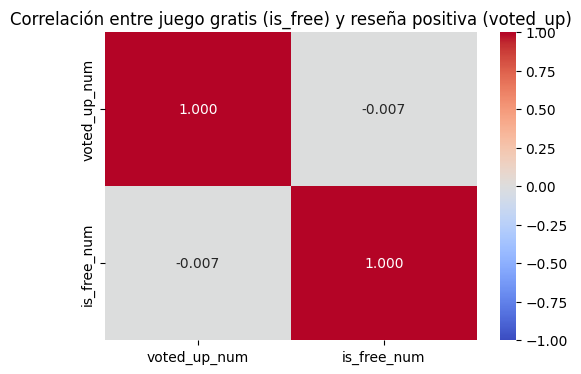


Tabla de contingencia (Cantidades reales):


voted_up,False,True
is_free,,
False,237409,758403
True,13169,39167


In [12]:
# 1. Cargar el dataset de aplicaciones
df_apps = pd.read_csv('data/applications.csv')

# 2. Hacer un merge entre las reseñas (df) y las aplicaciones usando 'appid'
# Usamos 'inner' para asegurarnos de cruzar solo los juegos que existen en ambos datasets
df_merged = df.merge(df_apps[['appid', 'is_free']], on='appid', how='inner')

# 3. Convertir las columnas booleanas (voted_up e is_free) a tipo numérico (float)
df_merged['voted_up_num'] = df_merged['voted_up'].astype(float)
df_merged['is_free_num'] = df_merged['is_free'].astype(float)

# 4. Calcular la matriz de correlación
plt.figure(figsize=(6, 4))
corr_is_free = df_merged[['voted_up_num', 'is_free_num']].corr()

# 5. Graficar el mapa de calor
sns.heatmap(corr_is_free, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title("Correlación entre juego gratis (is_free) y reseña positiva (voted_up)")
plt.show()

# (Opcional) Podemos imprimir también la tabla cruzada para ver cantidades absolutas
print("\nTabla de contingencia (Cantidades reales):")
display(pd.crosstab(df_merged['is_free'], df_merged['voted_up']))
